In [27]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds

In [28]:
ds = dds(model="extended standard nontwist map")

In [29]:
ds.info

{'description': 'Extended version of standard nontwist map',
 'has_jacobian': True,
 'has_backwards_map': True,
 'mapping': CPUDispatcher(<function extended_standard_nontwist_map at 0x11bc8afc0>),
 'jacobian': CPUDispatcher(<function extended_standard_nontwist_map_jacobian at 0x11bc8b4c0>),
 'backwards_mapping': CPUDispatcher(<function extended_standard_nontwist_map_backwards at 0x11bc8b240>),
 'dimension': 2,
 'number_of_parameters': 4,
 'parameters': ['a', 'b', 'c', 'm']}

In [30]:
a = 0.805
b = 0.597
c = 0.005
ms = [1, 2, 3, 4]
num_ic = 100000
total_time = 5000

In [31]:
np.random.seed(13)
x = np.random.rand(num_ic)
y = np.zeros_like(x)
u = np.stack([x, y]).T

In [32]:
averages = []
cumul_averages = []
for i in range(len(ms)):
    parameters = [a, b, c, ms[i]]
    ds.set_parameters(parameters)
    average = ds.average_in_time(u, total_time) 
    averages.append(average)
    cumul_average = ds.cumulative_average(u, total_time, parameters=parameters)
    cumul_averages.append(cumul_average)

(-2.0, 2.0)

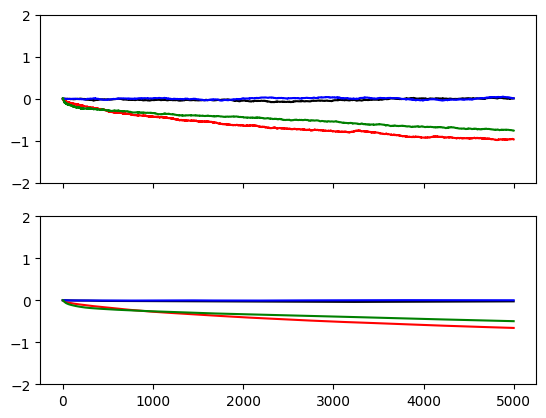

In [33]:
fig, ax = plt.subplots(2, 1, sharex=True)
colors = ["k", "r", "b", "g"]
for i in range(len(ms)):
    ax[0].plot(averages[i], c=colors[i])
    ax[1].plot(cumul_averages[i], c=colors[i])
ax[0].set_ylim(-2, 2)
ax[1].set_ylim(-2, 2)